<a href="https://colab.research.google.com/github/kabirans7/CRM_Coursework2/blob/main/TaskAQuestionG_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install git+https://github.com/pycaret/pycaret.git@master

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-dny8uq8c
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-dny8uq8c
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# numpy and pandas will be used for data manipulation
import numpy as np
import pandas as pd
# matplotlib will be used for visually representing our data
import matplotlib.pyplot as plt
# Yfinance will be used for importing historical oil prices
import yfinance as yfin

In [3]:
# Setting our ticker
ticker = 'AMZN'
ticker = yfin.Ticker(ticker)


# Importing our data
data = ticker.history(period='5y')

<Axes: xlabel='Date', ylabel='Crude Oil Prices: Brent - Europe'>

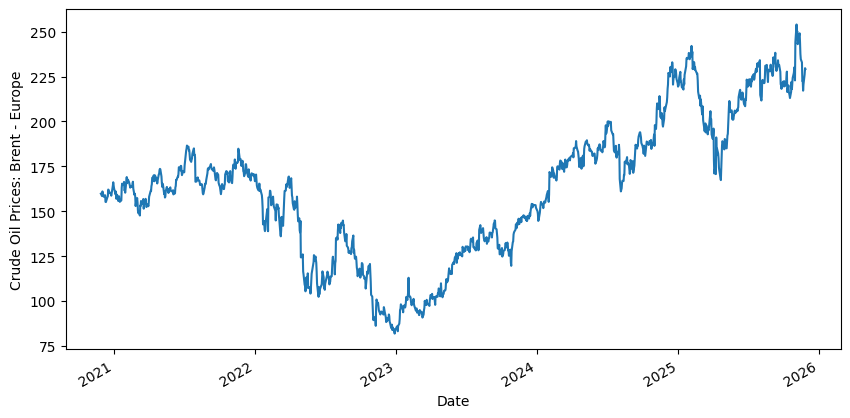

In [4]:
# Setting the text on the Y-axis
plt.ylabel("Crude Oil Prices: Brent - Europe")

# Setting the size of our graph
data['Close'].plot(figsize=(10,5))

In [5]:
data['SMA_20'] = data['Close'].shift(1).rolling(window=20).mean()
data['SMA_50']= data['Close'].shift(1).rolling(window=50).mean()
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

In [6]:
data.head(20)

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,SMA_50,EMA_20
Date,,,,,,,,,,
2020-11-27 00:00:00-05:00,160.563004,160.809494,159.502502,159.766998,47858000,0.0,0.0,NaN,NaN,159.766998
2020-11-30 00:00:00-05:00,160.423996,161.419495,156.277496,158.401993,81278000,0.0,0.0,NaN,NaN,159.636998
2020-12-01 00:00:00-05:00,159.425003,162.447495,157.858994,161.003998,90740000,0.0,0.0,NaN,NaN,159.767188
2020-12-02 00:00:00-05:00,161.082504,161.600006,158.662994,160.176498,62586000,0.0,0.0,NaN,NaN,159.806170
2020-12-03 00:00:00-05:00,160.272995,161.432007,159.065506,159.336502,57840000,0.0,0.0,NaN,NaN,159.761440
2020-12-04 00:00:00-05:00,159.910507,159.910507,157.938004,158.128998,58272000,0.0,0.0,NaN,NaN,159.605969
2020-12-07 00:00:00-05:00,157.824005,159.037994,157.084503,157.899994,55026000,0.0,0.0,NaN,NaN,159.443495
2020-12-08 00:00:00-05:00,157.945007,159.206497,156.001007,158.864502,65726000,0.0,0.0,NaN,NaN,159.388353
2020-12-09 00:00:00-05:00,158.394501,158.721497,154.399994,155.210007,82016000,0.0,0.0,NaN,NaN,158.990415


In [7]:
# Dropping the NaN values
data = data.dropna()

# Initialising X and assigning the two feature variables
X = data[['EMA_20','SMA_50']]

# Getting the head of the data
X.head()

,EMA_20,SMA_50
Date,,
2021-02-10 00:00:00-05:00,163.888376,160.86130
2021-02-11 00:00:00-05:00,163.813912,160.95254
2021-02-12 00:00:00-05:00,163.820730,161.04663
2021-02-16 00:00:00-05:00,163.785184,161.10426
2021-02-17 00:00:00-05:00,163.942024,161.16968


In [8]:
# Dropping the NaN values
data = data.dropna()

# Initialising X and assigning the two feature variables
X = data[['SMA_20','EMA_20','SMA_50', 'Close']]

# Getting the head of the data
X.head()

,SMA_20,EMA_20,SMA_50,Close
Date,,,,
2021-02-10 00:00:00-05:00,162.862074,163.888376,160.86130,164.328995
2021-02-11 00:00:00-05:00,163.276449,163.813912,160.95254,163.106506
2021-02-12 00:00:00-05:00,163.517049,163.820730,161.04663,163.885498
2021-02-16 00:00:00-05:00,163.892649,163.785184,161.10426,163.447495
2021-02-17 00:00:00-05:00,164.304399,163.942024,161.16968,165.432007


In [9]:
# Setting the training set to 80% of the data
training = 0.7
t = int(training*len(X))

# Training dataset
data_train= X[:t]

# Testing dataset
data_test = X[t:]

In [10]:
from pycaret.regression import *
s = setup(
    data=data[['SMA_20','SMA_50','EMA_20','Close']],
    target='Close',
    session_id=123,
    numeric_features=['SMA_20','SMA_50','EMA_20'],
    fold_strategy='timeseries', # Ensures temporal integrity
    data_split_shuffle=False,     # Prevents random shuffling
    n_jobs=-1
)

,Description,Value
0,Session id,123
1,Target,Close
2,Target type,Regression
3,Original data shape,"(1206, 4)"
4,Transformed data shape,"(1206, 4)"
5,Transformed train set shape,"(844, 4)"
6,Transformed test set shape,"(362, 4)"
7,Numeric features,3
8,Preprocess,True
9,Imputation type,simple


In [11]:
# Create a Linear Regression model
lr = create_model('lr')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8603,11.9323,3.4543,0.7378,0.0198,0.0165
1,1.9480,5.7872,2.4057,0.8113,0.0140,0.0114
2,4.6215,30.1986,5.4953,0.7521,0.0367,0.0311
3,3.6332,21.1777,4.6019,0.8672,0.0393,0.0312
4,3.4257,18.2439,4.2713,0.9156,0.0407,0.0325
5,1.5223,4.0553,2.0138,0.8960,0.0208,0.0159
6,1.5052,3.2477,1.8021,0.9747,0.0154,0.0129
7,3.0973,13.1611,3.6278,0.5869,0.0271,0.0233
8,1.9924,6.0824,2.4663,0.9431,0.0155,0.0127


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [12]:
tuned_lr = tune_model(lr)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.0088,7.2835,2.6988,0.8399,0.0153,0.0115
1,1.9401,5.8498,2.4186,0.8092,0.0140,0.0114
2,4.6020,29.3660,5.4190,0.7590,0.0361,0.0309
3,3.6212,21.0792,4.5912,0.8678,0.0393,0.0311
4,3.4007,18.0674,4.2506,0.9164,0.0405,0.0322
5,1.4827,3.7490,1.9362,0.9039,0.0200,0.0155
6,1.5248,3.3294,1.8247,0.9741,0.0156,0.0130
7,3.1092,13.2461,3.6395,0.5843,0.0272,0.0233
8,1.9856,6.0270,2.4550,0.9437,0.0155,0.0127


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 2 candidates, totalling 20 fits


In [13]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [14]:
rf = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8.1570,104.3085,10.2132,-1.2924,0.0589,0.0460
1,4.2778,25.7990,5.0793,0.1587,0.0298,0.0255
2,11.4323,224.2059,14.9735,-0.8402,0.1009,0.0809
3,11.6739,172.1981,13.1224,-0.0799,0.1075,0.0988
4,9.5080,155.0600,12.4523,0.2825,0.1201,0.0974
5,6.2797,51.3098,7.1631,-0.3157,0.0747,0.0651
6,6.3085,69.4358,8.3328,0.4589,0.0759,0.0543
7,14.6943,265.2567,16.2867,-7.3252,0.1277,0.1087
8,5.9599,48.4287,6.9591,0.5473,0.0468,0.0390


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [15]:
tuned_rf = tune_model(rf)


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,8.8868,116.8223,10.8084,-1.5674,0.0625,0.0502
1,4.1804,24.6663,4.9665,0.1957,0.0291,0.0249
2,11.1302,209.3831,14.4701,-0.7185,0.0979,0.0788
3,15.5294,293.2312,17.1240,-0.8389,0.1406,0.1365
4,10.6585,184.5323,13.5843,0.1461,0.1297,0.1087
5,6.0692,49.2400,7.0171,-0.2627,0.0731,0.0629
6,8.0631,95.5954,9.7773,0.2550,0.0912,0.0706
7,10.9738,155.5418,12.4716,-3.8818,0.0956,0.0808
8,11.3813,152.0782,12.3320,-0.4216,0.0843,0.0741


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [16]:
print(tuned_rf)

RandomForestRegressor(n_jobs=-1, random_state=123)


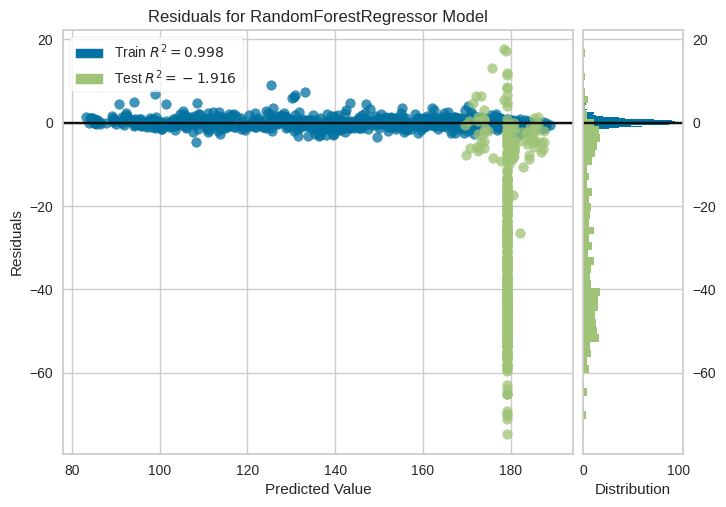

In [17]:
plot_model(tuned_rf)

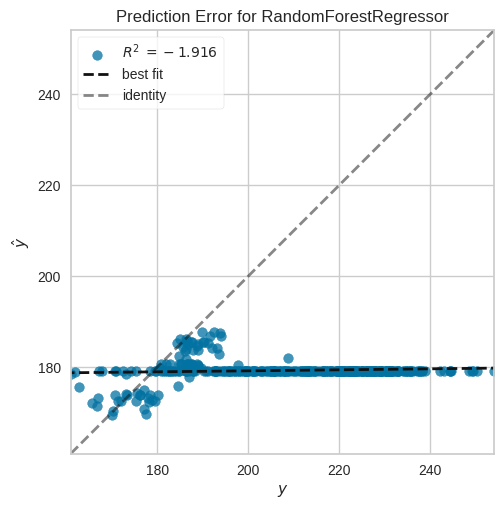

In [18]:
plot_model(tuned_rf, plot = 'error')

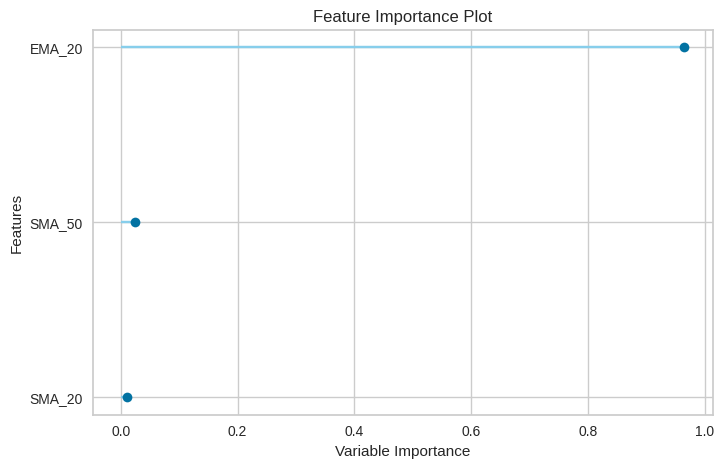

In [19]:
plot_model(tuned_rf, plot = 'feature')

In [20]:
evaluate_model(tuned_rf)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [21]:
predict_model(tuned_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,29.2965,1235.1282,35.1444,-1.9160,0.1735,0.1332


,SMA_20,SMA_50,EMA_20,Close,prediction_label
Date,,,,,
2024-06-20 00:00:00-04:00,182.590500,182.943207,183.712769,186.100006,183.486100
2024-06-21 00:00:00-04:00,182.738007,182.951797,184.223938,189.080002,183.857101
2024-06-24 00:00:00-04:00,183.035507,183.014404,184.352127,185.570007,184.384598
2024-06-25 00:00:00-04:00,183.261505,182.944794,184.541458,186.339996,184.096398
2024-06-26 00:00:00-04:00,183.541000,182.949005,185.405121,193.610001,182.840499
...,...,...,...,...,...
2025-11-20 00:00:00-05:00,236.597504,228.172806,232.476379,217.139999,179.207601
2025-11-21 00:00:00-05:00,236.399994,227.916595,231.353867,220.690002,179.207601
2025-11-24 00:00:00-05:00,236.223999,227.767395,230.870651,226.279999,179.207601


In [22]:
final_rf = finalize_model(tuned_rf)

In [23]:
print(final_rf)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['SMA_20', 'SMA_50', 'EMA_20'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequent'))),
                ('actual_estimator',
                 RandomForestRegressor(n_jobs=-1, random_state=123))])


In [24]:
predict_model(final_rf)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1.1869,2.9828,1.7271,0.9930,0.0085,0.0058


,SMA_20,SMA_50,EMA_20,Close,prediction_label
Date,,,,,
2024-06-20 00:00:00-04:00,182.590500,182.943207,183.712769,186.100006,185.456704
2024-06-21 00:00:00-04:00,182.738007,182.951797,184.223938,189.080002,187.650401
2024-06-24 00:00:00-04:00,183.035507,183.014404,184.352127,185.570007,185.843704
2024-06-25 00:00:00-04:00,183.261505,182.944794,184.541458,186.339996,185.949698
2024-06-26 00:00:00-04:00,183.541000,182.949005,185.405121,193.610001,190.765401
...,...,...,...,...,...
2025-11-20 00:00:00-05:00,236.597504,228.172806,232.476379,217.139999,219.400700
2025-11-21 00:00:00-05:00,236.399994,227.916595,231.353867,220.690002,222.216801
2025-11-24 00:00:00-05:00,236.223999,227.767395,230.870651,226.279999,226.306599


In [25]:
unseenrf_predictions = predict_model(final_rf, data=data_test)
unseenrf_predictions

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1.1869,2.9828,1.7271,0.9930,0.0085,0.0058


,SMA_20,EMA_20,SMA_50,Close,prediction_label
Date,,,,,
2024-06-20 00:00:00-04:00,182.590500,183.712769,182.943207,186.100006,185.456704
2024-06-21 00:00:00-04:00,182.738007,184.223938,182.951797,189.080002,187.650401
2024-06-24 00:00:00-04:00,183.035507,184.352127,183.014404,185.570007,185.843704
2024-06-25 00:00:00-04:00,183.261505,184.541458,182.944794,186.339996,185.949698
2024-06-26 00:00:00-04:00,183.541000,185.405121,182.949005,193.610001,190.765401
...,...,...,...,...,...
2025-11-20 00:00:00-05:00,236.597504,232.476379,228.172806,217.139999,219.400700
2025-11-21 00:00:00-05:00,236.399994,231.353867,227.916595,220.690002,222.216801
2025-11-24 00:00:00-05:00,236.223999,230.870651,227.767395,226.279999,226.306599


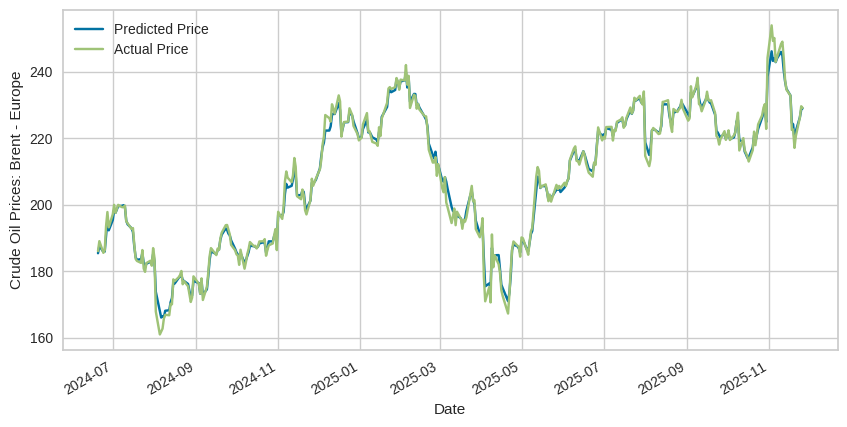

In [26]:
predictedrf_price = pd.DataFrame(unseenrf_predictions,index=unseenrf_predictions.index,columns = ['prediction_label'])
predictedrf_price.plot(figsize=(10,5))
unseenrf_predictions['Close'].plot()
plt.legend(['Predicted Price','Actual Price'])
plt.ylabel("Crude Oil Prices: Brent - Europe")
plt.show()